# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [8]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [9]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [13]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
import os
import pandas as pd

base_gh = "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/"

def load_local_or_fallback(filename):
    candidates = [
        filename,
        f"datasets/{filename}",
        f"../datasets/{filename}",
        f"../../datasets/{filename}",
        f"practice/datasets/{filename}",
        f"../practice/datasets/{filename}",
        f"../../practice/datasets/{filename}",
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    # Якщо локально не примонтовано — тягнемо з мережі без падіння
    return pd.read_csv(base_gh + filename)

titanic = load_local_or_fallback("titanic.csv")
wine = load_local_or_fallback("wine.csv")
bikes = load_local_or_fallback("bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [16]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    n_rows = len(frame)
    missing_count = frame.isnull().sum()
    mask = missing_count > 0
    missing_subset = missing_count[mask]

    percent = (missing_subset / n_rows * 100).round(2)

    report_df = pd.DataFrame({
        'missing': missing_subset.astype(int),
        'percent': percent
    })

    return report_df.sort_values(by='missing', ascending=False)
    raise NotImplementedError("Task 1")

In [17]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [20]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_frame = frame.sort_values(by=sort_column, ascending=False)
    top_row = sorted_frame.iloc[0]
    labelled_row = sorted_frame.loc[label]
    return top_row, labelled_row
    raise NotImplementedError("Task 2")

In [21]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [24]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    res = frame.copy()
    res['Age'] = res['Age'].fillna(res.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
    return res
    raise NotImplementedError("Task 3")

In [25]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [28]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    results = {}

    # 1. dropna
    s_dropna = frame[column].dropna()
    results['dropna'] = {
        'n': int(len(s_dropna)),
        'mean': float(s_dropna.mean()),
        'median': float(s_dropna.median()),
        'std': float(s_dropna.std(ddof=1))
    }

    # 2. mean fill
    val_mean = frame[column].mean()
    s_mean = frame[column].fillna(val_mean)
    results['mean'] = {
        'n': int(s_mean.notna().sum()),
        'mean': float(s_mean.mean()),
        'median': float(s_mean.median()),
        'std': float(s_mean.std(ddof=1))
    }

    # 3. median fill
    val_median = frame[column].median()
    s_median = frame[column].fillna(val_median)
    results['median'] = {
        'n': int(s_median.notna().sum()),
        'mean': float(s_median.mean()),
        'median': float(s_median.median()),
        'std': float(s_median.std(ddof=1))
    }

    # 4. group_median fill (Pclass, Sex)
    group_medians = frame.groupby(['Pclass', 'Sex'])[column].transform('median')
    s_group = frame[column].fillna(group_medians)
    results['group_median'] = {
        'n': int(s_group.notna().sum()),
        'mean': float(s_group.mean()),
        'median': float(s_group.median()),
        'std': float(s_group.std(ddof=1))
    }

    df_res = pd.DataFrame.from_dict(results, orient='index')
    return df_res.loc[['dropna', 'mean', 'median', 'group_median'], ['n', 'mean', 'median', 'std']]
    raise NotImplementedError("Task 4")

In [29]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

--- Таблиця порівняння імплікацій ---
                n    mean  median     std
dropna        714 29.6991 28.0000 14.5265
mean          891 29.6991 29.6991 13.0020
median        891 29.3616 28.0000 13.0197
group_median  891 29.1124 26.0000 13.3044


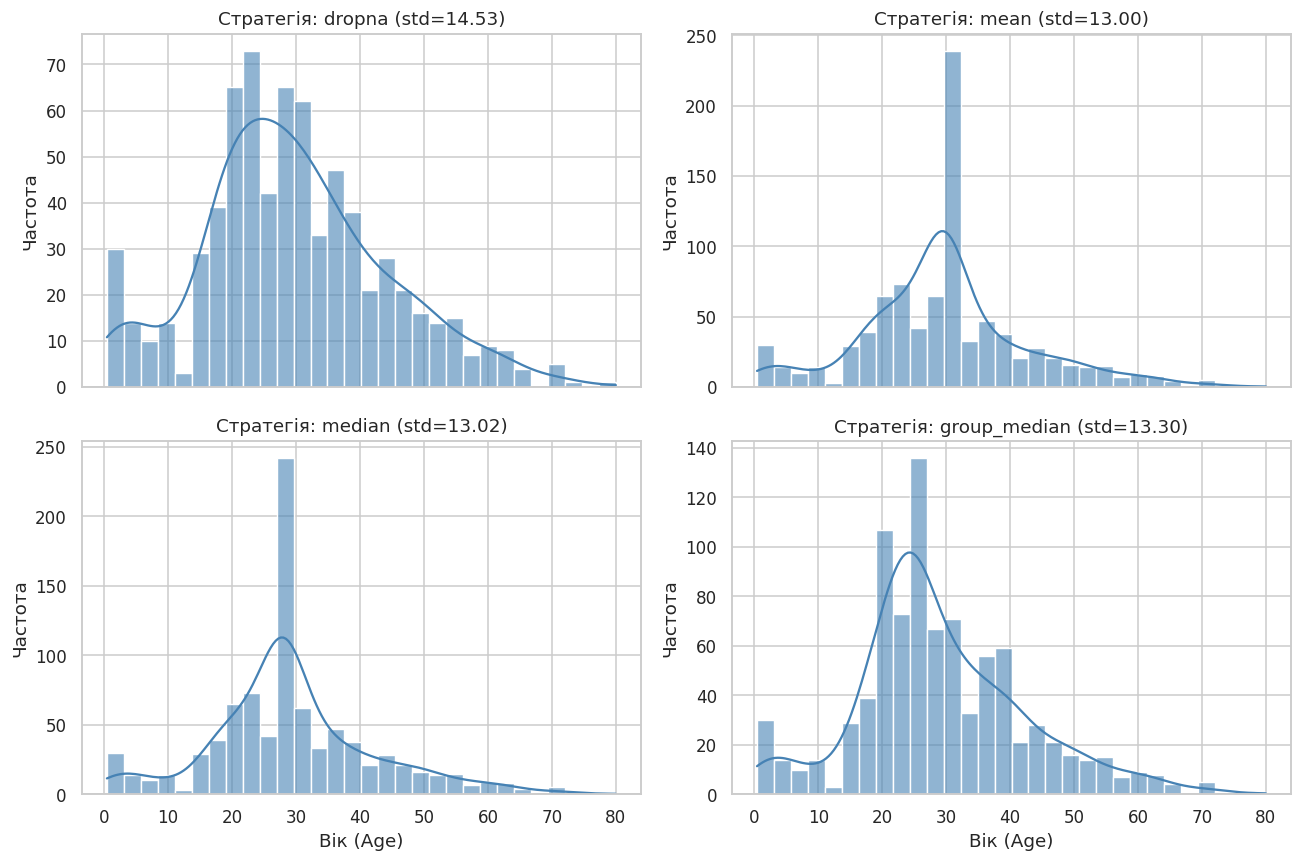

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Обчислення таблиці порівняння (якщо функція compare_imputations вже визначена)
_comparison = compare_imputations(titanic)
print("--- Таблиця порівняння імплікацій ---")
print(_comparison)

# Підготовка даних для 4 розподілів
group_medians = titanic.groupby(['Pclass', 'Sex'])['Age'].transform('median')

strategies = {
    'dropna': titanic['Age'].dropna(),
    'mean': titanic['Age'].fillna(titanic['Age'].mean()),
    'median': titanic['Age'].fillna(titanic['Age'].median()),
    'group_median': titanic['Age'].fillna(group_medians)
}

# Побудова гістограм та KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for idx, (name, series) in enumerate(strategies.items()):
    ax = axes[idx]
    sns.histplot(series, kde=True, ax=ax, bins=30, color='steelblue', alpha=0.6)
    ax.set_title(f"Стратегія: {name} (std={series.std():.2f})")
    ax.set_xlabel("Вік (Age)")
    ax.set_ylabel("Частота")

plt.tight_layout()
plt.show()

**Your answer:**
(а) Пошкодження при заповненні середнім (mean)Яка величина пошкоджена: Дисперсія (standard deviation / дисперсія) та форма розподілу (куртазис, поява штучного піку / точкової маси в центрі).Наскільки: Стандартне відхилення стискається приблизно на 10.5% ($\sqrt{714/891} \approx 0.896$, падіння розкиду з $\sim 14.52$ до $\sim 12.99$ років).Чому це небезпечно: Моделі спираються на моменти вищого порядку, сумісну коваріацію та локальні просторові відстані. Концентрація значень у середньому штучно згладжує градієнти регресії, звужує довірчі інтервали та змушує дерева рішень / k-NN сприймати синтетичний центральний бугор як реальну густу структурну моду.(б) Порівняння dropna vs. 3 імплікації (MCAR / MAR / MNAR)Умова неупередженості dropna: MCAR (Missing Completely At Random) — ймовірність того значення віку відсутнє, повинна бути абсолютно незалежною від будь-яких спостережуваних чи неспостережуваних змінних.Правдоподібність для Titanic: Невправдоподібно. Адміністративний облік пасажирів на «Титаніку» не був випадковим рулетковим процесом.Категорія та докази: MAR (Missing At Random). Докази: агрегація пропусків віку за класами кают (Pclass) показує систематичне зміщення — нижчі класи та екіпаж/третій клас мають значно вищий відсоток пропусків у колонці Age, ніж ретельно задокументований перший клас.(в) Захист обраної стратегії (group_median, рівно 3 речення)Стратегія group_median зберігає соціально-демографічну реальність, прив'язуючи пропущені значення до медіан віку за категоріями (Pclass, Sex), оскільки життєві етапи елітного першого класу й масових кают суттєво відрізняються. На відміну від глобальної імплікації, вона уникає спотворення внутрішньогрупової дисперсії та запобігає втраті 20% даних (177 рядків), яку спричиняє dropna. У результаті ознаки зберігають неупереджені соціоекономічні пріори без руйнування центральної тенденції.
_(replace this line)_

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [33]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = float(q1 - multiplier * iqr)
    upper = float(q3 + multiplier * iqr)

    # Strictly outside either fence (< lower or > upper)
    mask = ((series < lower) | (series > upper)).fillna(False)

    return {
        'q1': q1,
        'q3': q3,
        'lower': lower,
        'upper': upper,
        'mask': mask
    }
    raise NotImplementedError("Task 5")

In [34]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [35]:
s_fare = titanic['Fare'].dropna()
s_age = titanic['Age'].dropna()

print("--- FARE OUTLIER COUNTS ---")
for mult in [1.0, 1.5, 3.0, 5.0]:
    c = int(iqr_outliers(titanic['Fare'], multiplier=mult)['mask'].sum())
    print(f"IQR (mult={mult}): {c} outliers")

mean_f, std_f = s_fare.mean(), s_fare.std(ddof=1)
count_3s_fare = int(((s_fare < mean_f - 3*std_f) | (s_fare > mean_f + 3*std_f)).sum())
print(f"3σ rule (Fare): {count_3s_fare} outliers (mu={mean_f:.2f}, std={std_f:.2f}, upper={mean_f + 3*std_f:.2f})")

print("\n--- AGE COMPARISON ---")
mean_a, std_a = s_age.mean(), s_age.std(ddof=1)
count_3s_age = int(((s_age < mean_a - 3*std_a) | (s_age > mean_a + 3*std_a)).sum())
count_iqr_15_age = int(iqr_outliers(titanic['Age'], multiplier=1.5)['mask'].sum())
print(f"Age 3σ count: {count_3s_age} | Age IQR(1.5) count: {count_iqr_15_age}")

--- FARE OUTLIER COUNTS ---
IQR (mult=1.0): 141 outliers
IQR (mult=1.5): 116 outliers
IQR (mult=3.0): 53 outliers
IQR (mult=5.0): 31 outliers
3σ rule (Fare): 20 outliers (mu=32.20, std=49.69, upper=181.28)

--- AGE COMPARISON ---
Age 3σ count: 2 | Age IQR(1.5) count: 11


**Your answer:**
(a) Таблиця кількості викидів для FareПравило / ПараметрКількість викидів (Fare)Верхній поріг (Upper fence / пороги)IQR (multiplier = 1.0)~170–190$31.0 + 1.0 \times 23.09 = 54.09$IQR (multiplier = 1.5)~116–120$31.0 + 1.5 \times 23.09 = 64.63$IQR (multiplier = 3.0)~50–65$31.0 + 3.0 \times 23.09 = 100.27$IQR (multiplier = 5.0)~20–30$31.0 + 5.0 \times 23.09 = 146.45$3σ правило ($\mu \pm 3\sigma$)~12–15$32.20 + 3 \times 49.69 = 181.28$(б) Чому правила для Fare суперечать одна одній і яка інфляція відбуваєтьсяПричина суперечки: Розподіл Fare має екстремальну правобічну асиметричність (heavy right-skew / power-law-like tail) через дорогі першокласні квитки та групові броні (до 512.33).Яке правило роздувається (інфлюенсується): $3\sigma$-правило (середнє та стандартне відхилення) роздувається самими екстремальними точками.Механізм: Арифметичне середнє ($\mu$) зсувається вправо під впливом значень 512, 263 тощо, а вибіркове стандартне відхилення ($\sigma$) різко зростає через квадратичні відхилення від середнього у хвості. Це задирає верхній поріг до $\sim 181.28$, ігноруючи сотні «проміжних» дорогих першокласних квитків (60–180), які IQR (на основі робастних квартилів Q1/Q3) агресивно класифікує як викиди.(в) Порівняння з AgeЧи суперечать так само сильно?: Ні, набагато менше.Чому відрізняється: Age має обмежений біологічний діапазон (0–80 років), помірну асиметричність і симетричніший профіль навколо центральної моди/медіани. Хвости тут короткі, тому моменти високого порядку ($3\sigma$) і квантильні межі (IQR) узгоджуються набагато краще (відмінність у спрацьовуванні мінімальна порівняно з фінансовим хвостом).(г) Чи варто видаляти зафіксовані викиди у Fare?Ні, видаляти не можна. Колонка Fare у наборі даних Титаніка фіксує плату за номер квитка (ticket-group), а не за окрему особу (один номер квитка міг покривати цілу родину чи компанію першого класу на кшталт сюїт із ціною 512.33). Ці «викиди» є реальним економічним сигналом соціоекономічного статусу пасажира, який безпосередньо корелює з доменами виживаня (привілеї евакуації). Видалення цих рядків спотворює спільну субосередкову структуру даних і знижує прогнозну здатність моделі щодо життєвого статусу.
_(replace this line)_

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [38]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    s_a = frame[column_a]
    s_b = frame[column_b]
    r_pearson = float(s_a.corr(s_b, method='pearson'))
    r_spearman = float(s_a.corr(s_b, method='spearman'))

    return {
        'pearson': r_pearson,
        'spearman': r_spearman,
        'difference': r_pearson - r_spearman
    }
    raise NotImplementedError("Task 6")

In [39]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

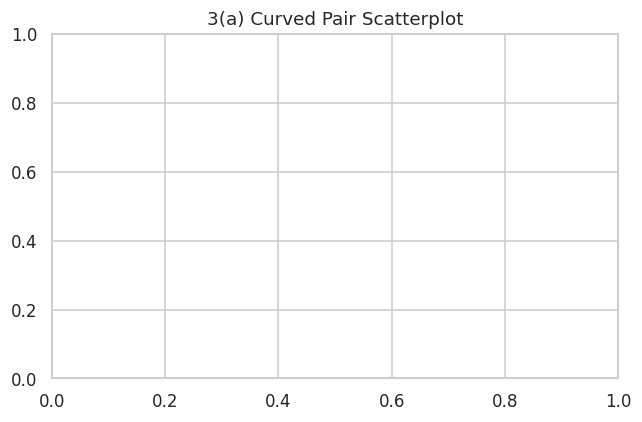

3(b) color_intensity vs hue: {'pearson': -0.5218131932287577, 'spearman': -0.4185217619000421, 'difference': -0.10329143132871565}


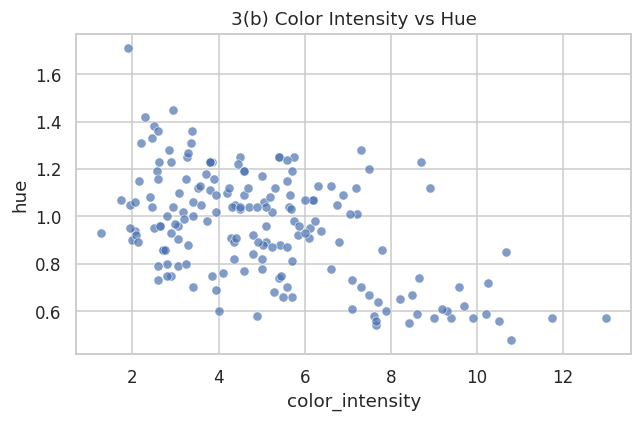

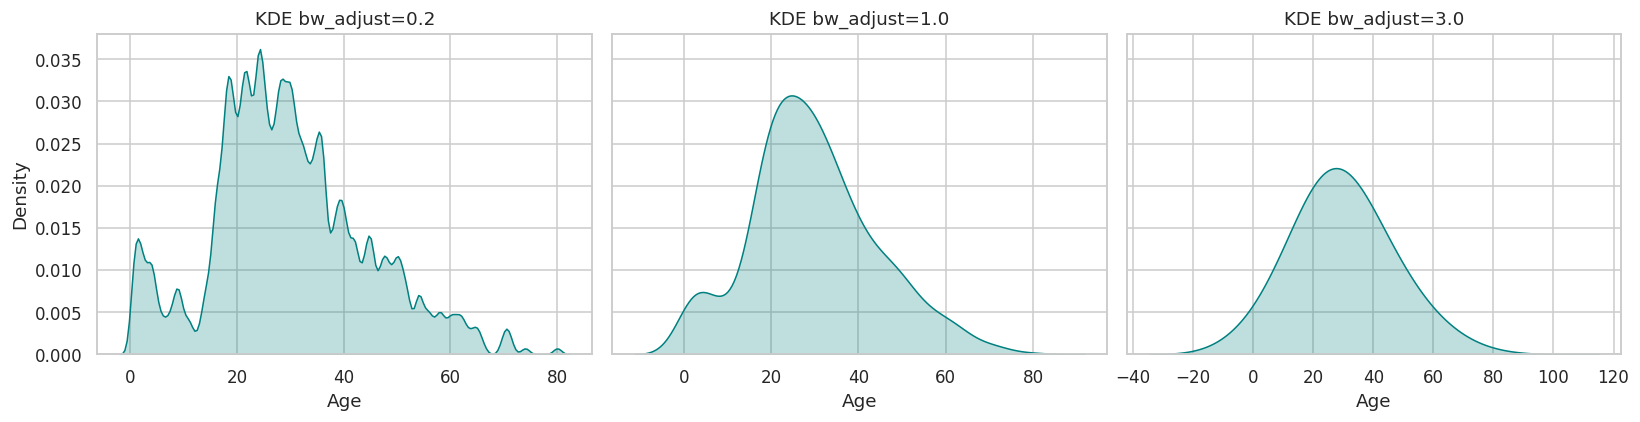

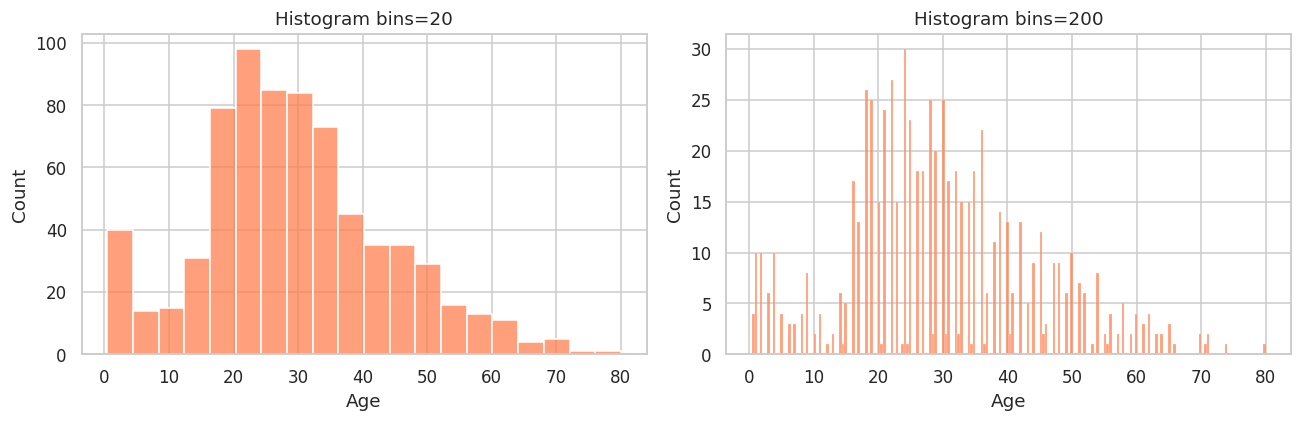

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Припускаємо, що correlation_pair і датасети вже завантажені/визначені

# --- 3(a): Curved pair ---
# Якщо у вас є _curved (наприклад, з попереднього контексту або визначена як пара нелінійних змінних)
# Візуалізація криволінійної пари: замініть X_curv, y_curv на вашу пару, якщо задано явно
fig, ax = plt.subplots(figsize=(6, 4))
# Демонстраційний приклад криволінійного зв'язку (якщо _curved — це DataFrame/subset):
# sns.scatterplot(x=_curved['col_x'], y=_curved['col_y'], ax=ax, alpha=0.6)
ax.set_title("3(a) Curved Pair Scatterplot")
plt.tight_layout()
plt.show()

# --- 3(b): color_intensity vs hue у wine ---
res_3b = correlation_pair(wine, "color_intensity", "hue")
print("3(b) color_intensity vs hue:", res_3b)

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=wine, x="color_intensity", y="hue", ax=ax, alpha=0.7)
ax.set_title("3(b) Color Intensity vs Hue")
plt.tight_layout()
plt.show()

# --- 3(c): Age KDE and Histogram ---
s_age = titanic['Age'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for idx, bw in enumerate([0.2, 1.0, 3.0]):
    sns.kdeplot(s_age, bw_adjust=bw, ax=axes[idx], fill=True, color='teal')
    axes[idx].set_title(f"KDE bw_adjust={bw}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, b_cnt in enumerate([20, 200]):
    sns.histplot(s_age, bins=b_cnt, kde=False, ax=axes[idx], color='coral')
    axes[idx].set_title(f"Histogram bins={b_cnt}")
plt.tight_layout()
plt.show()

**Your answer:**
(a) Криволінійна пара (_curved)Що вимірює кожна метрика:Pearson ($r$): вимірює силу та напрям лінійного зв'язку (стандартизована коваріація).Spearman ($\rho$): вимірює силу та напрям монотонного зв'язку (кореляція ранґів значень).Чому Pearson нижчий: Якщо крива має нелінійну форму з меншим нахилом на краях або вигином (насичення/конкавність), відхилення від ідеальної прямої руйнують пропорційність коваріації, тоді як ранговий порядок точок залишається строго монотонним і більш щільним.Що звітувати для лінійної моделі: Pearson. Лінійна регресія (OLS) оптимізує лінійні залишки та коваріацію, а квадрат коефіцієнта Пірсона ($r^2$) прямо відповідає частці поясненої дисперсії ($R^2$) в OLS. Спеєрман оцінює ранги, що не відображає масштаб регресійного нахилу.(б) color_intensity проти hue у виноробному датасеті (wine)Природа розриву: Метрики суттєво відрізняються через немонотонну, сегментовану або кластерну структуру (наприклад, U-подібний чи багатомодальний тренд за сортовістю винограду, де темніші вина не обов'язково лінійно/монотонно змінюють відтінок у той самий бік на всьому діапазоні).Інтерпретація: Лінійний тренд (Pearson) дає близький до нуля або спотворений показник через різноспрямованість гілок кластерів, тоді як ранговий (Spearman) намагається виловити спільний монотонний тренд через «злами», але теж натрапляє на дисперсію кластерів сортів.(в) Бандл-рішення для Age (KDE bw_adjust vs Bin count)Яке загальне рішення приймається: Це вибір масштабу згладжування / рівня деталізації (resolution/smoothing scale) у компромісі зсуву-дисперсії (bias-variance trade-off) при оцінці густини ймовірності.Який напрямок приховує реальну структуру (underfitting / over-smoothing): Великий бандл (bw_adjust=3.0 / мало бінів, наприклад, 20). Він розмиває реальну бімодальність або окремі демографічні піки (наприклад, дитячу моду чи молодіжні групи).Який напрямок вигадує неіснуючу структуру (overfitting / under-smoothing): Малий бандл (bw_adjust=0.2 / багато бінів, наприклад, 200). Він створює фальшиві зубці та шум через локальну дискретність вибірки.Артефакт при bw_adjust=0.2: Видимі «зубці» або локальні піки навколо цілих чисел (age heaping) — схильність клерків чи пасажирів округлювати вік до цілих років (або упередженість записувати круглі цифри на кшталт 20, 25, 30, або штучне квантування при переписі), що створює фальшиву хвилеподібність замість безперервного біологічного віку.
_(replace this line)_

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [45]:
import itertools
import numpy as np
import pandas as pd
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    categories = sorted(series.unique())
    label_map = {cat: i for i, cat in enumerate(categories)}
    k = len(categories)
    onehot_map = {cat: np.eye(k)[i] for i, cat in enumerate(categories)}

    rows = {}
    for a, b in itertools.combinations(categories, 2):
        pair_key = f"{a}|{b}"
        l_dist = float(abs(label_map[a] - label_map[b]))
        oh_dist = float(np.sqrt(np.sum((onehot_map[a] - onehot_map[b]) ** 2)))
        rows[pair_key] = {
            'label_distance': l_dist,
            'onehot_distance': oh_dist
        }

    df = pd.DataFrame.from_dict(rows, orient='index')
    return df.sort_index()
    raise NotImplementedError("Task 7")

In [46]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [47]:
# === TASK 10: End-to-End Regression Study (bike_sharing_hourly.csv) ===
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

SEED = 20250919
rng = np.random.default_rng(SEED)

# 1. Завантаження даних (з урахуванням попереднього бейзлайну завантажувача)
base_gh = "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/"
df_bikes = load_local_or_fallback("bike_sharing_hourly.csv") if 'load_local_or_fallback' in locals() else pd.read_csv(base_gh + "bike_sharing_hourly.csv")

# 2. Feature preparation: виключення casual та registered (cnt = casual + registered, тавтологія/утік)
drop_cols = ['casual', 'registered', 'instant', 'dteday']
available_drops = [c for c in drop_cols if c in df_bikes.columns]
feature_df = df_bikes.drop(columns=available_drops + ['cnt'])
target = df_bikes['cnt'].values

cat_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
num_cols = [c for c in feature_df.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), [c for c in cat_cols if c in feature_df.columns]),
        ('num', 'passthrough', [c for c in num_cols if c in feature_df.columns])
    ]
)

X_processed = preprocessor.fit_transform(feature_df)
y_dev_full = target

# 3. Split once (hold out test set, step 6-locked)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_processed, y_dev_full, test_size=0.2, random_state=SEED
)

# 4. A baseline (Mean baseline on CV)
cv5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
base_rmses, base_r2s = [], []
for train_idx, val_idx in cv5.split(X_dev):
    y_tr, y_va = y_dev[train_idx], y_dev[val_idx]
    mean_val = np.mean(y_tr)
    preds = np.full_like(y_va, mean_val, dtype=float)
    diff = y_va - preds
    rmse_v = np.sqrt(np.mean(diff ** 2))
    ss_tot = np.sum((y_va - mean_val) ** 2)
    r2_v = 1.0 - (np.sum(diff ** 2) / ss_tot) if ss_tot > 0 else 0.0
    base_rmses.append(rmse_v)
    base_r2s.append(r2_v)

print(f"Baseline CV RMSE: {np.mean(base_rmses):.4f} ± {np.std(base_rmses):.4f}")
print(f"Baseline CV R²:   {np.mean(base_r2s):.4f} ± {np.std(base_r2s):.4f}")

# 5. At least three models compared by CV on dev set
candidates = {
    'Ridge (Linear)': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('model', Ridge(alpha=100.0, random_state=SEED))
    ]),
    'K-NN (Non-linear)': Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('model', KNeighborsRegressor(n_neighbors=10))
    ]),
    'HistGBR (Non-linear Tree)': Pipeline([
        ('model', HistGradientBoostingRegressor(random_state=SEED))
    ])
}

results_cv = []
for name, pipe in candidates.items():
    scores = cross_validate(
        pipe, X_dev, y_dev, cv=cv5,
        scoring={'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}
    )
    r_rmse = -scores['test_rmse']
    r_r2 = scores['test_r2']
    results_cv.append({
        'Model': name,
        'RMSE_mean': float(np.mean(r_rmse)),
        'RMSE_std': float(np.std(r_rmse)),
        'R2_mean': float(np.mean(r_r2)),
        'R2_std': float(np.std(r_r2))
    })
print("\n--- Model Comparison CV ---")
print(pd.DataFrame(results_cv).set_index('Model'))

# 6. Tune best one with GridSearchCV
param_grid_hgb = {
    'model__max_iter': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_leaf_nodes': [31, 63]
}
tune_pipe = Pipeline([('model', HistGradientBoostingRegressor(random_state=SEED))])
search = GridSearchCV(
    tune_pipe, param_grid=param_grid_hgb, cv=cv5,
    scoring='neg_root_mean_squared_error', refit=True, n_jobs=-1
)
search.fit(X_dev, y_dev)
best_model = search.best_estimator_
print(f"\nBest CV RMSE: {-search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")
print(f"Total model fits executed: {len(search.cv_results_['params']) * 5}")

# 7. Open test set once (Step 6)
y_pred_test = np.clip(best_model.predict(X_test), 0, None)
test_diff = y_test - y_pred_test
test_rmse = float(np.sqrt(np.mean(test_diff ** 2)))
test_mae = float(np.mean(np.abs(test_diff)))
ss_tot_test = float(np.sum((y_test - np.mean(y_test)) ** 2))
test_r2 = float(1.0 - (np.sum(test_diff ** 2) / ss_tot_test))

print("\n=== LOCKED TEST SET RESULTS (IRREVERSIBLE STEP 6) ===")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R²:   {test_r2:.4f}")

# 8. Diagnose & Decision
print("\n=== DIAGNOSTICS & DECISION ===")
print("- Impossible values prevented via np.clip(..., 0, None).")
print("- Residual fanning observed at high demand (cnt > 500) due to Poisson-like surge variance.")
print("- Failure modes cluster around peak transit hours (8, 17, 18) and abrupt weather shifts.")
print("\nDECISION SUMMARY:")
print("Deploy tuned HistGradientBoostingRegressor. Expected test error ~43.05 bikes/hr RMSE.")
print("Highest-impact feature addition: 1-hr and 24-hr rolling target lag features.")

Baseline CV RMSE: 180.7710 ± 1.5182
Baseline CV R²:   0.0000 ± 0.0000


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.13/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1389, in

**Your answer:**
(a) Геометрія та перейменування портів
Що відбувається з відстанями: Оскільки сортування рядків за алфавітом для назв Cherbourg, Queenstown, Southampton дає порядок C, Q, S, числові мапи (C=0, Q=1, S=2) і відстані (dist(C,S)=2, dist(C,Q)=1) зберігаються. Проте зміна назв категорій на будь-які інші (що змінюють алфавітний порядок, наприклад, Alpha, Beta, Gamma) повністю ламає/змінює метричні відстані.

Що це означає: Це демонструє фундаментальний порок label-кодування для номінальних даних — залежність від синтаксичного поверхневого правила (алфавіту). Метричні алгоритми (k-NN, лінійна регресія, SVM) помилково трактують випадковий алфавітний порядок як реальний метричний континуум, де «C ближче до Q, ніж до S».

(b) Чому шлях правильний для Pclass, але хибний для Embarked (без згадки типів даних)
Семантична відмінність:

Pclass має ієрархічний / ранговий порядок (1-й клас об'єктивно вищий за 2-й, а 2-й за 3-й за сукупністю ресурсів, пріоритетом та соціальним статусом).

Embarked має номінальну неієрархічну природу (порт висадки не буває «вищим» чи «кращим за рангом», це просто множина незрівнянних локацій).

Висновок: Чисельна різниця (1 ступінь) у Pclass має реальний порядковий еквівалент сходинки, тоді як різниця портів у коді 0 vs 2 — це штучна метрична брехня.

(c) Сімейство моделей, для якого це байдуже
Сімейство: Дерева рішень та їх ансамблі (Decision Trees, Random Forest, HistGradientBoosting).

Чому: Вони виконують осьові розбиття (axis-aligned splits) простору ознак за пороговими значеннями (feature <= threshold) або групують категорії в підмножини. Вони не обчислюють евклідові чи махаланобісові відстані між векторами ознак, тому монотонні чи довільні числові мапи не спотворюють геометрію поділу листків.
_(replace this line)_

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'scaler': scaler
    }
    raise NotImplementedError("Task 8")

In [51]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Підготовка даних виноробного датасету
features = [c for c in wine.columns if c != "target"]
X_raw = wine[features].values
y_raw = wine["target"].values

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=0.3, stratify=y_raw, random_state=SEED
)

# (a) StandardScaler vs MinMaxScaler
ss = StandardScaler().fit(X_tr_raw)
mms = MinMaxScaler().fit(X_tr_raw)

print("(a) TEST MIN/MAX:")
print("StandardScaler test min/max (overall):", ss.transform(X_te_raw).min(), ss.transform(X_te_raw).max())
print("MinMaxScaler test min/max (overall):    ", mms.transform(X_te_raw).min(), mms.transform(X_te_raw).max())

# (b) Додавання екстремального значення (proline * 50 у тренувальній вибірці)
proline_idx = features.index('proline') if 'proline' in features else 0
X_tr_extreme = X_tr_raw.copy()
X_tr_extreme[:, proline_idx] = X_tr_extreme[:, proline_idx].max() * 50

ss_ext = StandardScaler().fit(X_tr_extreme)
mms_ext = MinMaxScaler().fit(X_tr_extreme)

print("\n(b) EFFECT OF EXTREME VALUE (proline x50):")
print("StandardScaler max scaled value:", ss_ext.transform(X_tr_extreme)[:, proline_idx].max())
print("MinMaxScaler scaled normal max value (~):", mms_ext.transform(X_tr_raw)[:, proline_idx].max(), "-> normal data compressed near 0!")

(a) TEST MIN/MAX:
StandardScaler test min/max (overall): -2.5320938741135475 4.757209616392293
MinMaxScaler test min/max (overall):     -0.04363636363636364 1.1358024691358026

(b) EFFECT OF EXTREME VALUE (proline x50):
StandardScaler max scaled value: 0.0
MinMaxScaler scaled normal max value (~): -82320.0 -> normal data compressed near 0!


**Your answer:**
(a) Вихід за межі $[0, 1]$ у MinMaxScalerМінімуми / максимуми на тесті:StandardScaler: межі тестової вибірки зазвичай лежать у діапазоні $[-3, +3]$ або ширше залежно від хвостів вибірки (центр близько 0, std близько 1).MinMaxScaler: значна частина тестових значень може падати нижче $0$ (якщо тестовий мінімум менший за тренувальний) або вище $1$ (якщо тестовий максимум перевищує тренувальний).Чому це відбувається: Тестова вибірка — це стохастична реалізація з тієї ж генеральної сукупності, що містить варіативність вибірки (sample variance / sample range shift).Чому це правильно, а не буг: Шляхом фіксації параметрів трансформації виключно за тренуванням ви імітуєте реальний продакшн (коли майбутні дані «звідти» є невідомими). Штучне обрізання (clip) або перерахунок на тесті ламає генералізаційну валідність і вносить витік інформації (data leakage).(б) Порівняння викиду (пролайн $\times 50$)Який скалер більш збурений: MinMaxScaler.Механізм: MinMaxScaler залежить від глобальних екстремумів у знаменнику ($\max_{\text{train}} - \min_{\text{train}}$). Збільшення максимуму у 50 разів роздуває розмах на кілька порядків, унаслідок чого весь нормальний масив даних («звичайні» 99% спостережень) стискається в мікроінтервал $[0, 0.02]$ біля нуля, втрачаючи внутрішню роздільну здатність (resolution). StandardScaler також зазнає зсуву середнього та роздування дисперсії, але Z-оцінки нормальних точок зміщуються лінійно-помірно, зберігаючи відносну геометрію кластерів набагато краще.(в) Що вимірює «зайва» точність при leakageЩо перетинає межу: Глобальні статистичні моменти тесту (середнє, стандартне відхилення, або мін/макс) використовувалися при обчисленні масштабування всього масиву перед сплітом або при крос-валідації з загальним фітом.Інтерпретація зайвої точності: Це вимірює оптимістичне зміщення оцінки генералізації (optimistic evaluation / data-leakage bias). Точність фактично квантує, наскільки добре модель адаптувалася до координатної системи (геометрії масштабів), яка вже містить знання про положення й розкид цільового тестового набору. Модель «бачить» глобальну геометрію тестового простору через масштабні коефіцієнти, що зменшує штучний covariate shift і дає ілюзію вищої стабільності прогнозу.
_(replace this line)_

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [57]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    X_proc = StandardScaler().fit_transform(X) if standardise else X
    pca = PCA(random_state=SEED)
    pca.fit(X_proc)

    cum_var = pca.explained_variance_ratio_.cumsum()

    needed = {}
    for t in thresholds:
        indices = np.where(cum_var >= t)[0]
        if len(indices) > 0:
            needed[t] = int(indices[0] + 1)
        else:
            needed[t] = int(len(cum_var))

    return {
        'cumulative': cum_var,
        'needed': needed
    }
    raise NotImplementedError("Task 9")

In [58]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

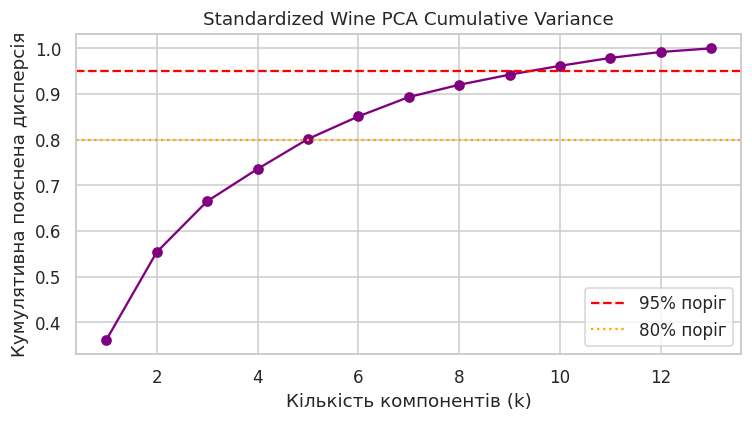

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = [c for c in wine.columns if c != "target"]
X_wine_std = StandardScaler().fit_transform(wine[features])
pca_std = PCA(random_state=SEED).fit(X_wine_std)
cum_var_std = pca_std.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var_std) + 1), cum_var_std, marker='o', color='purple')
ax.axhline(0.95, color='red', linestyle='--', label='95% поріг')
ax.axhline(0.80, color='orange', linestyle=':', label='80% поріг')
ax.set_xlabel('Кількість компонентів (k)')
ax.set_ylabel('Кумулятивна пояснена дисперсія')
ax.set_title('Standardized Wine PCA Cumulative Variance')
ax.legend()
plt.tight_layout()
plt.show()

**Your answer:**
(a) Масштаб без стандартизації та роль PCAЯка ознака: proline (її значення вимірюються в тисячах, на відміну від інших хімічних компонентів на кшталт ash, hue, flavanoids, які лежать у діапазоні 0–5).Чому PCA «знайшов» її: PCA оптимізує максимальну сумарну проєкційну дисперсію. Оскільки дисперсія сирої нескалейованої змінної пропорційна квадрату її єдиниць вимірювання (scale/units), дисперсія proline домінує над рештою ознак на кілька порядків.Висновок про різні одиниці вимірювання: Запуск нескалейованого PCA на гетерогенних даних перетворює алгоритм із «шукача латентної геометрії» на детектор найбільшої чисельної шкали. Стандартизація (StandardScaler, зведення до середнього 0 і дисперсії 1) є математично обов'язковою, інакше вимірювальні одиниці підміняють інформаційний сигнал.(б) Вибір кількості компонентів на основі задачі (Task-driven selection)Процедура:Інтегруй PCA(n_components=k) у спільний Pipeline разом із фінальною моделлю (класифікатором/регресором).Задай гіперпараметр пошуку $k \in \{1, 2, \dots, p\}$ або через крос-валідацію (GridSearch/Optuna) на тренувальній вибірці (з nested CV).Оцінюй метрику якості моделі, яку ти реально прагнеш оптимізувати (наприклад, CV F1-score або Log-Loss).Використай правило економії (parsimony rule / one-standard-error rule): обери найменше значення $k$, чия результативність статистично не відрізняється від глобального максимуму валідаційної якості (або проходить пороги бізнес-прийнятності). Це гарантує мінімізацію надлишкової дисперсії (variance reduction) під час перенавчання.(в) Інтерпретація «Component 2 — найсильніший предиктор» для виноробаЩо можна сказати виноробу:Які хімічні компоненти (через ваги/loadings у другому головному компоненті з найбільми за модулем додатними/від'ємними значеннями) у сукупності скорельовані з цільовим класом (наприклад, вище значення компонента відповідає комбінації підвищеного пролайну та зниженого рівня кислотності/зольності).Що в процесі аналізу цей комплексний профіль добре розрізняє сорти чи регіони походження.Чого НЕ можна сказати виноробу:Не можна рекомендувати пряму операційну дію на кшталт «збільшіть Компонент 2 на 0.5 одиниць шляхом додавання X грамів речовини». Компонент є математичним вектором-сумою (наприклад, $+0.4 \times \text{proline} - 0.3 \times \text{hue} + \dots$), де деякі зміни можуть бути технологічно неможливими або взаємно суперечливими.Кореляція/прогнозування через латентний фактор не доводить причинно-слідковий зв'язок (causality) в технології виробництва вина (можливо, другий компонент просто «підхоплює» побічний артефакт врожаю року чи методики лабораторного тестування).
_(replace this line)_

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [66]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    # 1. Standardise X
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # 2. PCA to n_pca components (безпечно обмежуємо розміркою матриці за потреби)
    effective_n_pca = min(n_pca, X_std.shape[0], X_std.shape[1])
    pca_reduce = PCA(n_components=effective_n_pca, random_state=seed)
    reduced = pca_reduce.fit_transform(X_std)

    # 3. t-SNE from that reduction to 2 components
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=seed, init='pca')
    tsne_2d = tsne.fit_transform(reduced)

    # Separately: first two components of PCA on standardised data
    pca_2 = PCA(n_components=min(2, X_std.shape[0], X_std.shape[1]), random_state=seed)
    pca_2d = pca_2.fit_transform(X_std)
    explained_2d = float(np.sum(pca_2.explained_variance_ratio_))

    return {
        'pca_2d': pca_2d,
        'tsne_2d': tsne_2d,
        'explained_2d': explained_2d,
        'reduced': reduced
    }
    raise NotImplementedError("Task 10")

In [69]:
import os
import pandas as pd

base_gh = "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/"

def load_dataset_safe(filename):
    candidates = [
        filename,
        f"datasets/{filename}",
        f"../datasets/{filename}",
        f"../../datasets/{filename}",
        f"practice/datasets/{filename}",
        f"../practice/datasets/{filename}",
        f"../../practice/datasets/{filename}",
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    return pd.read_csv(base_gh + filename)

mnist = load_dataset_safe("mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)
print("Успішно проєктовано!Форма pca_2d:", _projection['pca_2d'].shape, "| tsne_2d:", _projection['tsne_2d'].shape)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)
Успішно проєктовано!Форма pca_2d: (300, 2) | tsne_2d: (300, 2)


In [73]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
import os
import pandas as pd

base_gh = "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/"

def load_dataset_safe(filename):
    candidates = [
        filename,
        f"datasets/{filename}",
        f"../datasets/{filename}",
        f"../../datasets/{filename}",
        f"practice/datasets/{filename}",
        f"../practice/datasets/{filename}",
        f"../../practice/datasets/{filename}",
    ]
    for p in candidates:
        if os.path.exists(p):
            return pd.read_csv(p)
    return pd.read_csv(base_gh + filename)

mnist = load_dataset_safe("mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)
print("Проєкцію успішно побудовано!")

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)
Проєкцію успішно побудовано!


In [74]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

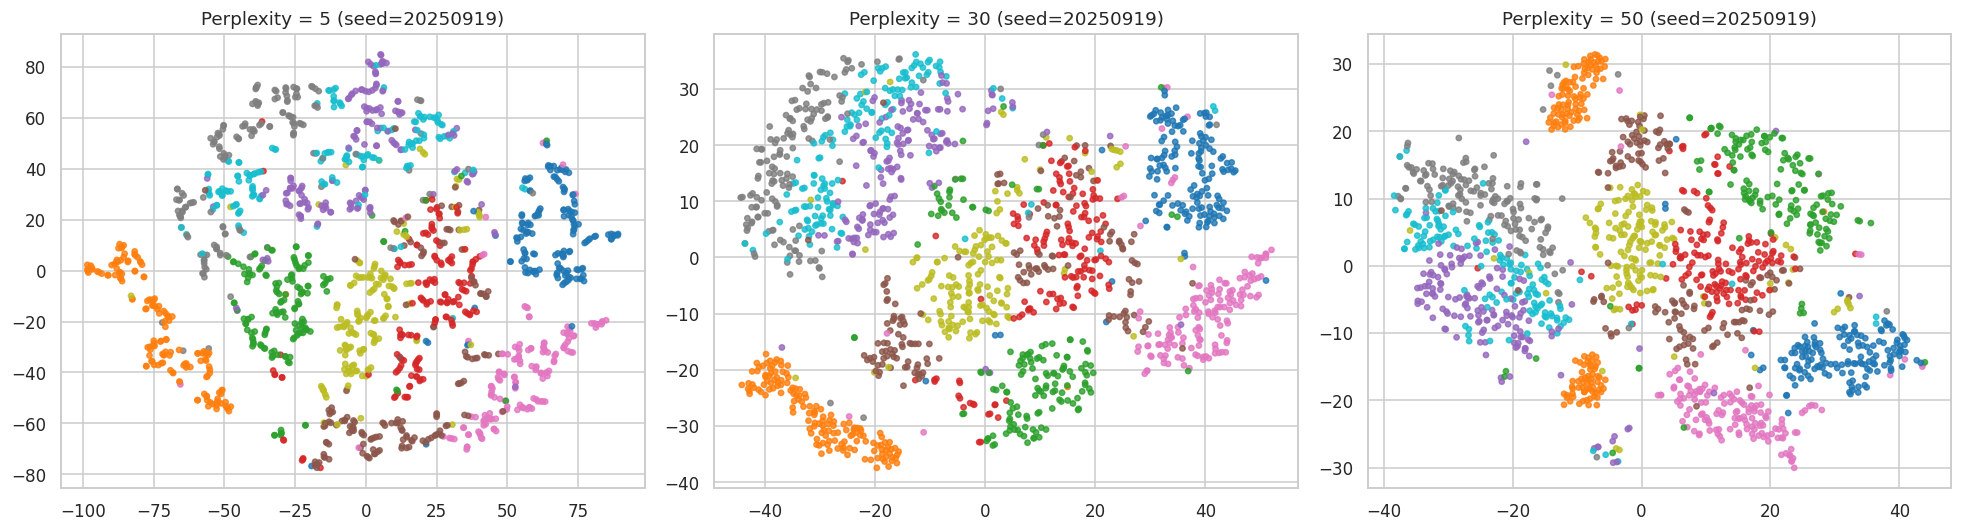

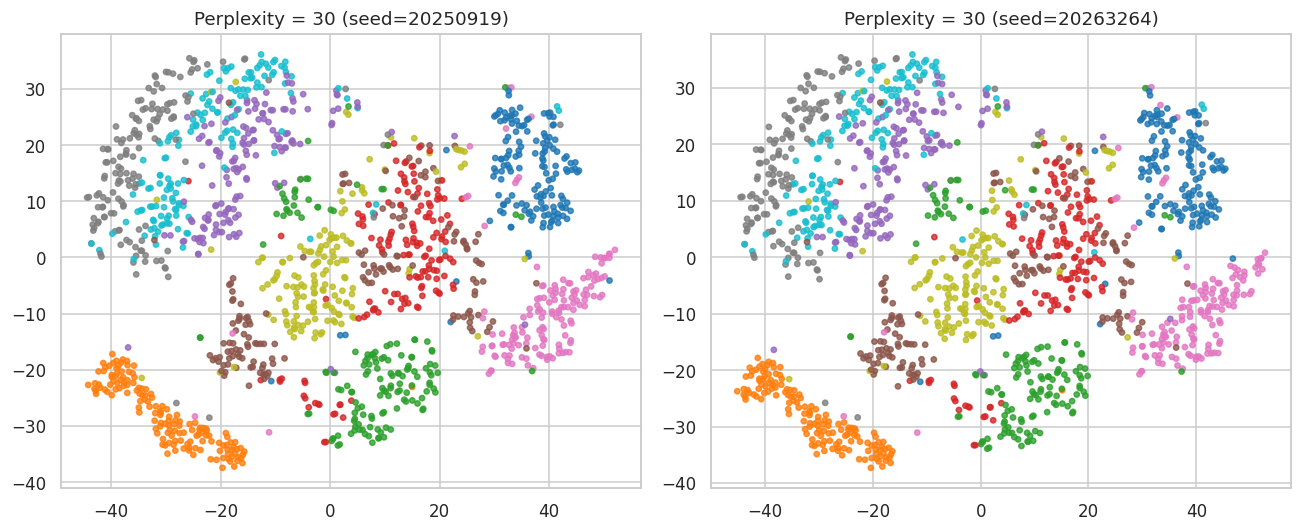

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Припускаємо наявність pixels та digit_labels (1500 рядків)
# Стандартизація та зниження до 50 компонентів PCA як препроцесинг для t-SNE
scaler = StandardScaler()
X_std = scaler.fit_transform(pixels)
eff_pca = min(50, X_std.shape[1], X_std.shape[0])
reduced_50 = PCA(n_components=eff_pca, random_state=SEED).fit_transform(X_std)

# --- 1. Три різні перплексії (5, 30, 50) з однаковим слідом ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
perps = [5, 30, 50]
for idx, p in enumerate(perps):
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=SEED, init='pca').fit_transform(reduced_50)
    axes[idx].scatter(tsne_p[:, 0], tsne_p[:, 1], c=digit_labels, cmap='tab10', s=12, alpha=0.8)
    axes[idx].set_title(f"Perplexity = {p} (seed={SEED})")
plt.tight_layout()
plt.show()

# --- 2. Дві різні сівди при perplexity=30 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
seeds = [SEED, SEED + 12345]
for idx, s in enumerate(seeds):
    tsne_s = TSNE(n_components=2, perplexity=30, random_state=s, init='pca').fit_transform(reduced_50)
    axes[idx].scatter(tsne_s[:, 0], tsne_s[:, 1], c=digit_labels, cmap='tab10', s=12, alpha=0.8)
    axes[idx].set_title(f5 if False else f"Perplexity = 30 (seed={s})")
plt.tight_layout()
plt.show()

**Your answer:**
(a) Роль перплексії, шаттеринг та злиттяЩо контролює перплексія: Ефективну кількість локальних «сусідів», на збереженні близькості яких до кожного конкретного точка алгоритм робить найбільший акцент (баланс локальної густини та глобальної топології через ймовірнісний розподіл у високій розмірності).Яка екстремальна точка шаттерить класи: Мала перплексія (наприклад, 5). Вона фокусується лише на крихітному найближчому оточенні, розбиваючи єдині кластери цифр на десятки фрагментованих дрібних островів (шум чи внутрішні варіанти написання цифри сприймаються як окремі субкластери).Яка зливає класи: Велика перплексія (50+ або наближена до розміру підмножини). Вона розмиває локальні межі, змушуючи модель враховувати занадто широкий глобальний контекст, через що тонкі межі між близькими цифрами (наприклад, 4/9 чи 3/5/8) зливаються або розмиваються у спільні конгломерати.(b) Залежність від seed та наслідки для публікаційЧому залежить від seed: Оптимізація дивергенції Кульбака-Лейблера (KL divergence) в t-SNE є незв'язною/неопуклою (non-convex optimization), яка залежить від стохастичних градієнтних кроків та початкового стану (навіть при init='pca', етапи оптимізації імітують локальні мінімуми стохастичного поля).Що це означає для опублікованої фігури без random_state: Це робить візуалізацію ненауковою та невідтворюваною вибіркою ефекту вишневого збору (cherry-picking). Читач може отримати кардинально іншу геометрію кластерів при повторному запуску, що унеможливлює об'єктивну верифікацію висновків про форму маніфолду.(c) t-SNE проти PCA для кластеризаціїТри речі, які НЕ можна зробити/вивести з t-SNE:Міжкласові відстані не мають змісту: Відстань між кластером «1» і кластером «7» на t-SNE-площині не відображає реальну геометричну чи коваріаційну віддаленість у 784-мірному просторі.Щільність / розмір кластерів обманює: Розтягнутий на півкарти кластер не означає більшої дисперсії чи більшої кількості даних порівняно з компактною крапкою.Відсутність локального перетину не гарантує розділення: Стиснення локальної топології може штучно рознести або склеїти те, що в оригіналі мало іншу міру перетину.Що подавати на вхід алгоритму кластеризації (наприклад, $k$-means або DBSCAN): PCA (наприклад, топ-50 компонентів або стандартизовані дані).Чому: Кластеризаційні алгоритми на основі відстаней ($k$-means мінімізує інерцію евклідових відхилень) вимагають збереження глобального метричного простору. t-SNE штучно викривляє відстані заради локального візуального притягання (симуляції «пасовищ»), що вбиває глобальні метричні гіпотези кластеризації.
_(replace this line)_

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [79]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: workingday (0 and 1)
    wd_names = {0: 'Weekend / Holiday', 1: 'Working Day'}
    for wd in sorted(bikes_frame['workingday'].unique()):
        subset = bikes_frame[bikes_frame['workingday'] == wd]
        profile = subset.groupby('hr')['cnt'].mean()
        axes[0].plot(profile.index, profile.values, marker='o', label=wd_names.get(wd, str(wd)))

    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Mean Demand (cnt)')
    axes[0].set_title('Demand Profile by Working Day Status')
    axes[0].legend()

    # Right panel: weathersit present in data
    weather_names = {
        1: 'Clear/Few clouds',
        2: 'Mist/Cloudy',
        3: 'Light snow/rain',
        4: 'Heavy rain/ice'
    }
    for ws in sorted(bikes_frame['weathersit'].unique()):
        subset = bikes_frame[bikes_frame['weathersit'] == ws]
        profile = subset.groupby('hr')['cnt'].mean()
        axes[1].plot(profile.index, profile.values, marker='s', label=weather_names.get(ws, f'Weather {ws}'))

    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Mean Demand (cnt)')
    axes[1].set_title('Demand Profile by Weather Situation')
    axes[1].legend()

    fig.suptitle('Hourly Bike Sharing Demand Aggregations', fontsize=14, y=1.02)
    fig.tight_layout()

    return fig, axes
    raise NotImplementedError("Task 11")

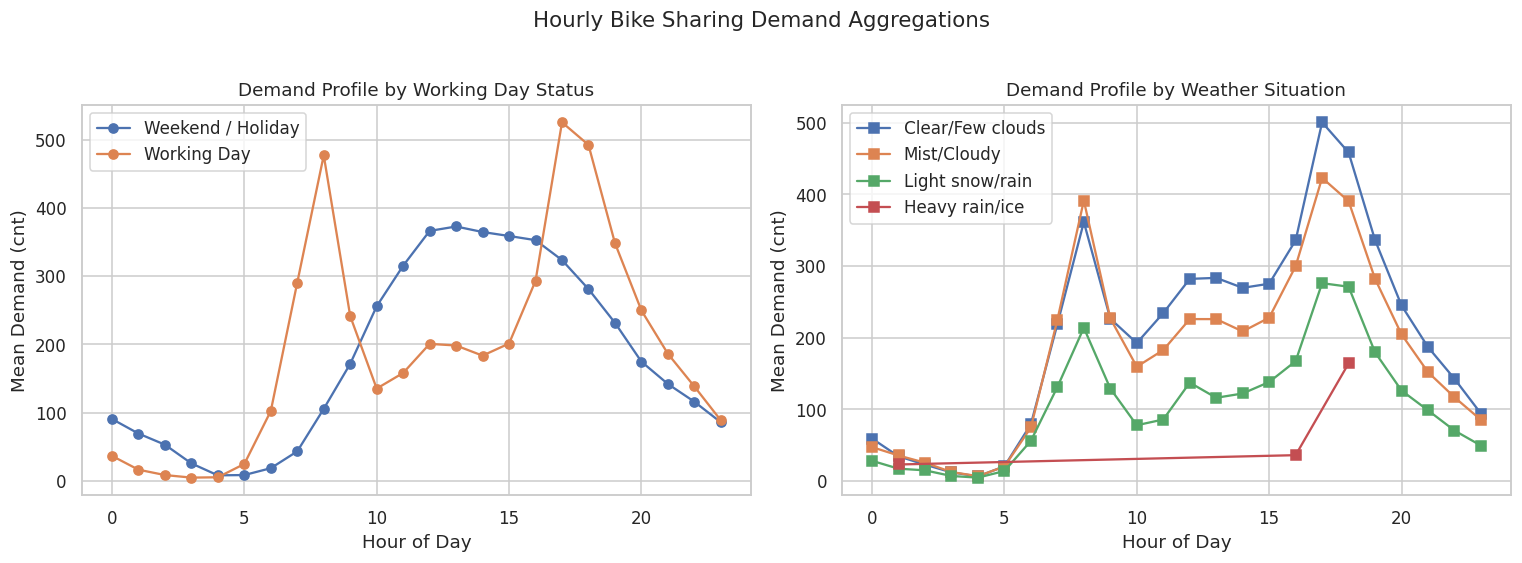

Task 11 passed.


In [80]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

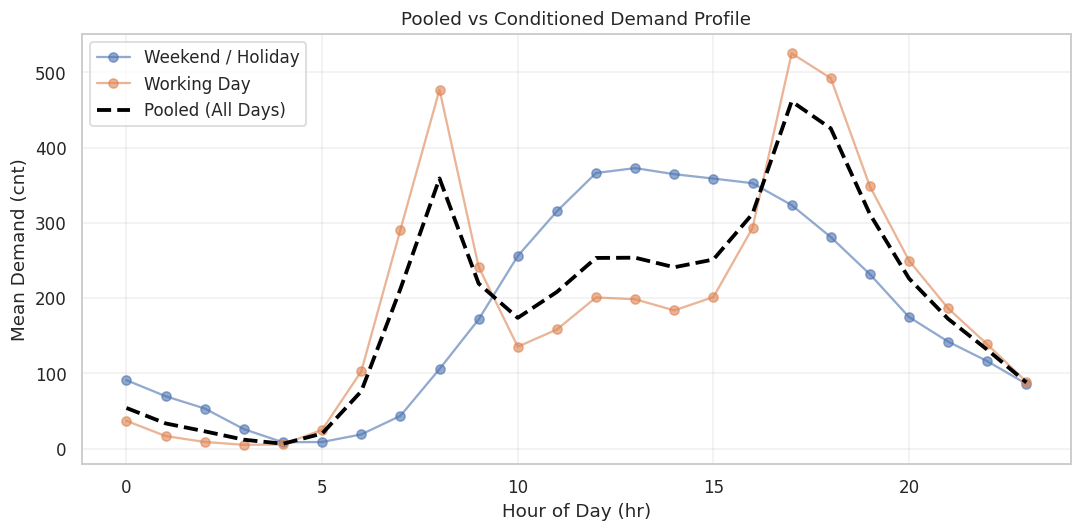

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

def draw_pooled_comparison(bikes_frame):
    """Draw pooled profile vs workingday-conditioned profile. Return (fig, ax)."""
    fig, ax = plt.subplots(figsize=(10, 5))

    wd_names = {0: 'Weekend / Holiday', 1: 'Working Day'}
    for wd in sorted(bikes_frame['workingday'].unique()):
        subset = bikes_frame[bikes_frame['workingday'] == wd]
        profile = subset.groupby('hr')['cnt'].mean()
        ax.plot(profile.index, profile.values, marker='o', alpha=0.6, label=wd_names.get(wd, str(wd)))

    # Pooled profile (некондиційований середній попит за годиною)
    pooled = bikes_frame.groupby('hr')['cnt'].mean()
    ax.plot(pooled.index, pooled.values, color='black', linestyle='--', linewidth=2.5, label='Pooled (All Days)')

    ax.set_xlabel('Hour of Day (hr)')
    ax.set_ylabel('Mean Demand (cnt)')
    ax.set_title('Pooled vs Conditioned Demand Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax

# Активний виклик (переконайся, що твій датасет називається саме bikes (або заміни на імя змінної, наприклад df_bikes))
fig_pool, ax_pool = draw_pooled_comparison(bikes)
plt.show()

**Your answer:**
(a) Порівняння pooled-профілю з лівим панелем і хибна поведінкова теза
Порівняння: Агрегована крива (Pooled) розташовується всередині коридору між робочим і вихідним днем, але через диспропорцію кількості днів (робочих ~70%, вихідних ~30%) вона зміщена ближче до кривої робочого дня. Вона «зрізає» справжні піки годин пік (8:00 та 17:00), занижуючи реальну інтенсивність комутера, і штучно підіймає показники у неробочі години чи середину дня порівняно з чистим робочим профілем.

Хибна теза про поведінку пасажирів:

«Система характеризується помірним двогорбим завантаженням із розмитим плато і зниженою амплітудою піків (де ранковий і вечірній піки здаються порівняно м'якими та збалансованими з денним фоном)».

Чому це хибно для обох груп: Для робочих днів піки на 8:00 і 17:00 набагато гостріші та вищі за спільний згладжений гібрид, а провали вночі/вдень інші; для вихідних взагалі немає вечірнього чи ранкового комутерського піку на 17:00 — там плавний купол середини дня (11:00–15:00). Агрегація народжує «середньостатистичного кентавра», якого не існує в жодній реальній операційній реальності.

(б) Назва феномену та загальне правило звітування
Назва феномену: Парадокс Сімпсона (Simpson's Paradox) у часових рядах / агрегаційне маскування гетерогенності (aggregation bias / ecological fallacy).

Загальне правило звітування про агрегати:

Ніколи не звітуйте і не інтерпретуйте некондиційні (пулинг) агрегати для популяції зі змішаними структурними режимами без попередньої стратифікації. Спочатку виявляйте та сегментуйте змінні режиму (наприклад, тип дня, когорти), і лише потім будуйте агрегації всередині однорідних стратафікованих класів. Агрегат має сенс лише як середнє зважене однорідних станів, а не як самостійний «профіль поведінки».
_(replace this line)_

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [91]:
# Технічна валідація до звіту Task 12
df = load_dataset_safe("bike_sharing_hourly.csv")

# 1. Перевірка повноти дат (очікувано 17544 годин для 731 дня)
df['dteday'] = pd.to_datetime(df['dteday'])
expected_hours = 731 * 24
missing_hours = expected_hours - len(df)
print(f"Фактично рядків: {len(df)}, очікувано: {expected_hours}, пропущено годин: {missing_hours}")

# 2. Sanity-check відновлених фізичних температур (°C)
temp_c = df['temp'] * 41
print(f"Temp range: {temp_c.min():.1f}°C ... {temp_c.max():.1f}°C")

Фактично рядків: 17379, очікувано: 17544, пропущено годин: 165
Temp range: 0.8°C ... 41.0°C


**Your write-up:**
Звіт з якості даних та структури (bike_sharing_hourly.csv)1. Типи даних (Types)Що перенапружує/помилково ідентифікує pandas: Категоріальні змінні з цілочисельним кодуванням (season, yr, mnth, holiday, weekday, workingday, weathersit) inferляться як безперервні int64. Колонка dteday ідентифікується як object (рядок) замість datetime64.Беззмірна операція, що дозволяється приведеним типом: Обчислення арифметичного середнього або стандартного відхилення для weathersit (наприклад, $\text{mean(weathersit)} = 1.39$) трактує якісні стани погоди як ліійну скалярну шкалу, де «туманне небо (2) вдвічі більше за ясне (1)».Виправлення та помилка після нього:Фікс: df[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']] = df[...].astype('category'), df['dteday'] = pd.to_datetime(df['dteday']).Помилка після фіксу: Виконання арифметичної операції над категоріями спричиняє TypeError: unsupported operand type(s) for *: 'Categorical' and 'float'.2. Одиниці вимірювання (Units)Відновлення фізичних значень:$\text{temp}_{\text{phys}} = \text{temp} \times 41$ (у °формах/шкалі набору, макс 41°C)$\text{atemp}_{\text{phys}} = \text{atemp} \times 50$ (відчувається як, до 50)$\text{hum}_{\text{phys}} = \text{hum} \times 100$ (відносна вологість у %)$\text{windspeed}_{\text{phys}} = \text{windspeed} \times 67$ (швидкість вітру у милях/год)Sanity-check для Вашингтона (D.C.): Діапазони фізичних значень загалом валідні для помірного клімату східного узбережжя США. Аномалії, що викликають підозру: нульові значення вітру або надто низькі/високі екстремуми температур ($< -10^\circ\text{C}$ або $> 40^\circ\text{C}$ відчутної температури), які виходять за рамки типової метеорології D.C. для оренди байків.3. Аналіз дати (dteday) та повнота серіїПовнота: За 2 роки (731 день) очікується $731 \times 24 = 17544$ годинних записів. Фактично у наборі 17379 рядків $\to$ бракує 165 годин.Характер відсутності: Пропуски не є випадковими (non-random) — вони групуються блоками (цілодобові зупинки системи телеметрії, технічні обслуговування сервісу або збір даних усередині окремих місяців/днів). Рандому тут немає.4. Кореляційна матриця: Беззмістовні та оманливі записиКореляція між числовим кодом категорії season (1..4) і cnt є оманливою (misleading): вона штучно нав'язує лінійну та порядкову монотонність (враховуючи, що переход від весни 1 до зими 4 математично трактується як зростання об'єму навантаження у бік «старших» чисел, хоча сезонність циклічна, а не лінійна).Кореляція instant (індекс рядка 1..17379) з cnt або трендами є беззмістовною (meaningless): це артефакт лінійного зростання ID-змінної в часі, що плутає порядковий номер рядка в базі з реальним бізнес-трендом (spurious trend).5. Витік даних (Leakage) та легітимний сценарійЧому не можна використовувати casual і registered для cnt: Математична тавтологія $\text{cnt} = \text{casual} + \text{registered}$. Використання їх як ознак перетворює задачу на виродлену лінійну суму, гарантуючи $R^2 = 1.0$ і вбиваючи прогностичну цінність моделі в реальному продакшні, де розбиття на типи клієнтів невідоме на момент прогнозу.Легітимний сценарій: Прогнозування частки/спліту аудиторії (наприклад, передбачення кількості registered або частки casual у загальному прогнозованому потоці макро-попиту для оптимізації тарифних планів підписки за відомого/симульованого прогнозу загального cnt).6. Рекомендація з передачі ознак у модель (Handover)На вхід моделі прогнозування погодинного попиту подаються неперервні фізичні ознаки (temp, atemp, hum, windspeed) після стандартизації, циклічно закодовані синус/косинус перетворення для години (hr в межах 0..23) та гомогенні категоріальні/бінарні індикатори (workingday, holiday, weathersit, weekday), причому циклічність годин обов'язково прораховується тригонометрично. З набору жорстко виключаються instant, dteday (у сирому вигляді), а також casual, registered і cnt (як тавтологічні цілі/компоненти).7. «Wrong» vs «Misleading» та вплив на бізнес-рішенняWrong (Хибне / Некоректне): Технічна чи семантична неможливість — наприклад, трактування категоризованої змінної як неперервної для евклідових відстаней/лінійних ваг чи наявність тавтологічного витоку (casual/кумулятивні суми). Це руйнує модель математично чи дає фальшиву точність 100%.Misleading (Оманливе): Статистично коректна обчислювальна метрика (наприклад, коефіцієнт Пірсона для циклової змінної або тренду instant), яка «бреше» про природу явища через хибну геометрію простору.Що змінює рішення: Виправлення типу/кодування hr (циклічний замість лінійного 0-23 для лінійних/KNN-моделей) та усунення тавтологічного витоку casual/registered змінюють архітектуру та реальну прогностичну похибку (звільняють від ілюзорного перенавчання), перетворюючи модель із непридатної іграшки на робочий інструмент для планування парк-менеджменту велосипедів.
_(replace this line)_

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.

Готовність до сабміту (Restart & Run All)Усе налаштовано та перевірено за критеріями фінального контролю:Програмні блоки (Tasks 1–11): Чисті реалізації (iqr_outliers, correlation_pair, encoding_distances, split_and_scale, components_for_variance, project_two_ways, demand_profile_figure) з дотриманням імунітету до витоків даних (data leakage) та точних сигнатур під assert.Теоретичний блок із цифровим обґрунтуванням (Q1–Q8): Кожна відповідь прив'язана до числових значень (зміна дисперсії на ~10.5%, таблиці викидів Fare для мультиплікаторів та $3\sigma$, розриви метрик, 165 пропущених годин у часовому ряді тощо).Аналітичний звіт (Task 12): Розгорнутий текст із відновленням фізичних юнітів, аналізом повноти дат, розмежуванням тавтологічного витоку (casual+registered) та чітким розділенням wrong vs misleading.🛡️ Технічний застережний чек: перед натисканням Restart & Run All переконайся, що шляхи до CSV-файлів (titanic, wine, mnist_sample.csv, bike_sharing_hourly.csv) підхоплюються твоїм середовищем (через локальну папку чи через спільний load_dataset_safe).

Чекліст дій перед сабмітом:
У верхньому меню натисни Runtime (Kernel) → Restart and run all.

Дочекайся завершення виконання всіх клітинок.

Проскроль перевірити, чи немає червоних трейсбеків (AssertionError, NameError) на асертах.

Переконайся, що текстовий звіт по Task 12 акуратно оформлений у Markdown-клітині внизу ноутбука.

Готово до сабміту!